In [1]:
import torchvision
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger
from enum import Enum
import json
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import TQDMProgressBar

In [2]:
import spoofdet.config as config
from spoofdet.efficient_net.model_utils import check_dataset_distribution, display_train_result, analyze_spoof_types, analyze_dataset_spoof_distribution, display_params, verify_subject_split, get_data_for_training
from spoofdet.train import train_model
from spoofdet.evaluate import evaluate_model
from spoofdet.data_processing import get_transform_pipeline, create_subset
from spoofdet.utils import check_image, check_augmented_image, save_results
from spoofdet.dataset import CelebASpoofDataset
from spoofdet.efficient_net.model import EfficientNetSpoofingDetection, get_model, freeze_stages, adaptive_batch_norm

d:\JoshFile\Github\spoofing-recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

## params

In [4]:


PARAM_MULTIPLIER = 1

MODEL_NAME = "efficientnet_v2_s"
BATCH_SIZE = 32 * PARAM_MULTIPLIER


EPOCHS = 50
EARLY_STOPPING_LIMIT = 10
TARGET_SIZE = 224  # 320
# TARGET_SIZE = config.TARGET_SIZE
LEARNING_RATE = 1e-3 * PARAM_MULTIPLIER

BACKBONE_LR = 1e-5
HEAD_LR = 3e-4


class ModelLR(Enum):
    backbone = BACKBONE_LR
    head = HEAD_LR


WEIGHT_DECAY = 1e-4 * PARAM_MULTIPLIER


NUM_UNFROZEN_LAYERS = 2


WORKERS = 2

SPOOF_PERCENT = 0.5
TRAIN_IMG_COUNT = 10000
VAL_IMG_COUNT = int(TRAIN_IMG_COUNT * 0.2)
# VAL_IMG_COUNT = 1000
TEST_IMG_COUNT = int(TRAIN_IMG_COUNT * 0.1)
# 0.001

## dataset

In [5]:
train_dict, val_dict = get_data_for_training(
    str(config.TRAIN_JSON), train_count=TRAIN_IMG_COUNT, val_count=VAL_IMG_COUNT)


train_transform, val_transform = get_transform_pipeline(
    target_size=TARGET_SIZE)

train_ds = CelebASpoofDataset(
    root_dir=config.ROOT_DIR,
    json_label_path=train_dict,
    bbox_json_path=config.BBOX_LOOKUP,
    target_size=TARGET_SIZE,
    bbox_original_size=config.BBOX_ORGINAL_SIZE,
    transform=train_transform

)

val_ds = CelebASpoofDataset(
    root_dir=config.ROOT_DIR,
    json_label_path=val_dict,
    bbox_json_path=config.BBOX_LOOKUP,
    target_size=TARGET_SIZE,
    bbox_original_size=config.BBOX_ORGINAL_SIZE,
    transform=val_transform
)

test_ds = CelebASpoofDataset(
    root_dir=config.ROOT_DIR,
    json_label_path=config.TEST_JSON,
    bbox_json_path=config.BBOX_LOOKUP,
    target_size=TARGET_SIZE,
    bbox_original_size=config.BBOX_ORGINAL_SIZE,
    transform=val_transform
)

Total training images: 494405
Subjects: 8192 total, 6553 train, 1639 val
Images: 395427 train, 98978 val
Subject-split - Train: 395427 Val: 98978
Training set: 10000 images
  Live: 5000 (50.0%)
  Spoof: 5000 (50.0%)
Validation set: 2000 images
  Live: 1000 (50.0%)
  Spoof: 1000 (50.0%)
Loading JSON metadata...
Processing metadata into optimized list...
Metadata processed. Dataset size: 10000
Loading JSON metadata...
Processing metadata into optimized list...
Metadata processed. Dataset size: 2000
Loading JSON metadata...
Processing metadata into optimized list...
Metadata processed. Dataset size: 67170


In [6]:

# # np.random.seed(seed)

# # small_train_ds = create_subset(train_ds, total_size=TRAIN_IMG_COUNT, spoof_percent=SPOOF_PERCENT)
# # small_val_ds = create_subset(val_ds, total_size=VAL_IMG_COUNT, spoof_percent=SPOOF_PERCENT)
small_test_ds = create_subset(test_ds, total_size=TEST_IMG_COUNT)
# # print(f"Created Balanced Train: {len(small_train_ds)} images")

 Found in this split: 19923 Live | 47247 Spoof


## dataloader

In [7]:
from torch.utils.data import DataLoader
small_train_loader = DataLoader(train_ds,
                                batch_size=BATCH_SIZE,
                                shuffle=True,
                                num_workers=WORKERS,
                                pin_memory=True,
                                persistent_workers=True,
                                drop_last=True


                                )
small_val_loader = DataLoader(val_ds,
                              batch_size=1,
                              shuffle=False,
                              num_workers=WORKERS,
                              pin_memory=True,
                              persistent_workers=True


                              )
small_test_loader = DataLoader(small_test_ds,
                               batch_size=1,
                               shuffle=False,
                               num_workers=WORKERS,
                               pin_memory=True,
                               persistent_workers=True,
                               drop_last=True
                               )

In [8]:
device = torch.device("cpu")

## model import

In [9]:
model_path = "tb_logs/mobile_net_v4/version_15/checkpoints/epoch=15-step=4992.ckpt"
model = EfficientNetSpoofingDetection.load_from_checkpoint(
    model_path, backbone_model="mobile_net_v4", strict=False)
model.eval()
# model.freeze()
# script = model.to_torchscript()
# torch.jit.save(script, "model.pt")
model.to(device)
quantize_model = model

d:\JoshFile\Github\spoofing-recognition\.venv\Lib\site-packages\lightning\pytorch\core\saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['criterion.pos_weight']


In [10]:
# from torch.ao.quantization import quantize_fx
# import os
# import torch
# import warnings

# warnings.filterwarnings("ignore", category=FutureWarning)
# warnings.filterwarnings("ignore", category=UserWarning)

# qconfig_dict = {"": torch.ao.quantization.get_default_qconfig("fbgemm")}


# example_input = torch.randn(1, 3, TARGET_SIZE, TARGET_SIZE)


# model_prepared = quantize_fx.prepare_fx(
#     quantize_model, qconfig_dict, example_input)  # type: ignore
# model_prepared.to(device)
# print("Calibrating...")

# with torch.no_grad():
#     # In real code, use ~50 images from your validation set
#     for i, (img, label) in enumerate(small_val_loader):
#         if i >= 50:
#             break
#         img = img.to(device)
#         model_prepared(img)

# # Convert
# model_quantized = quantize_fx.convert_fx(model_prepared)  # type: ignore

# # Check Size
# torch.save(model_quantized.state_dict(), "temp_quant_fx.pth")
# size_mb = os.path.getsize("temp_quant_fx.pth") / 1e6
# print(f"Final Quantized Size: {size_mb:.2f} MB")

# # Clean up
# # os.remove("temp_quant_fx.pth")

## torch onnx

In [11]:
dummy_input = torch.randn(1, 3, 224, 224)
fp32_path = "onnx/mobile_net_v4_ver15_fp32.onnx"
torch.onnx.export(
    model,
    (dummy_input,),
    fp32_path,
    opset_version=18,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    # dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

W0220 18:15:43.522000 34972 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0220 18:15:43.523000 34972 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0220 18:15:43.526000 34972 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0220 18:15:43.528000 34972 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]',

[torch.onnx] Obtain model graph for `EfficientNetSpoofingDetection([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNetSpoofingDetection([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 154 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu130',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"backbone.conv_stem.weight"<FLOAT,[32,3,3,3]>{Tensor(...)},
                %"backbone.blocks.0.0.conv_exp.weight"<FLOAT,[128,32,3,3]>{Tensor(...)},
                %"backbone.blocks.0.0.conv_pwl.weight"<FLOAT,[48,128,1,1]>{Tensor(...)},
                %"backbone.blocks.1.0.dw_start.conv.weight"<FLOAT,[48,1,3,3]>{Tensor(...)},
                %"backbone.blocks.1.0.pw_exp.conv.weight"<FLOAT,[192,48,1,1]>{Tensor(...)},
                %"backbone.blocks.1.0.dw_mid.conv.weight"<FLOAT,[192,1,5,5]>{Tensor(..

In [12]:
import onnx
import onnxruntime as ort
import numpy as np

# Check model
onnx_model = onnx.load(fp32_path)
onnx.checker.check_model(onnx_model)

# Run inference
ort_session = ort.InferenceSession(fp32_path)
ort_inputs = {ort_session.get_inputs()[0].name: dummy_input.numpy()}
ort_outputs = ort_session.run(None, ort_inputs)
print("ONNX output shape:", ort_outputs[0].shape)

ONNX output shape: (1, 1)


In [13]:
import torch
import onnxruntime
from onnxruntime.quantization import CalibrationDataReader, quantize_static, QuantType, QuantFormat


class DataLoaderReader(CalibrationDataReader):
    def __init__(self, dataloader, model_path, max_batches=50):
        self.dataloader = dataloader
        self.enum_data = iter(self.dataloader)
        self.max_batches = max_batches
        self.batch_counter = 0
        self.model_path = model_path

        # Get the input name from the ONNX model automatically
        session = onnxruntime.InferenceSession(
            self.model_path, providers=['CPUExecutionProvider'])
        self.input_name = session.get_inputs()[0].name

    def get_next(self):
        if self.batch_counter >= self.max_batches:
            print("Reached max batches, stopping.")
            return None
        try:
            images, _ = next(self.enum_data)
            print(
                f"Batch {self.batch_counter}: original tensor range [{images.min():.3f}, {images.max():.3f}], shape {images.shape}")
            input_data = images.cpu().numpy()
            print(
                f"After numpy: range [{input_data.min():.3f}, {input_data.max():.3f}]")
            self.batch_counter += 1
            return {self.input_name: input_data}
        except StopIteration:
            print("DataLoader exhausted.")
            return None

## f32 to int8

In [14]:
from onnxruntime.quantization import quantize_static, QuantType, QuantFormat, CalibrationMethod
from onnxruntime.quantization import quantize_dynamic, QuantType, quantize_static
from onnxruntime.quantization import QuantFormat
import onnx
from onnxruntime.quantization import shape_inference
import onnx
# 1. Load your FP32 model
input_path = "onnx/mobile_net_v4_ver15_fp32.onnx"
clean_path = "onnx/mobile_net_v4_ver15_fp32_clean.onnx"


model = onnx.load(fp32_path)
output_name = model.graph.output[0].name
print("Output tensor name:", output_name)

# Find the node that produces this output
for node in model.graph.node:
    if output_name in node.output:
        print("Output node name:", node.name, "op_type:", node.op_type)
        output_node_name = node.name
        break

# 2. Clear existing shape information (value_info)
# This removes the "256" hint causing the conflict
del model.graph.value_info[:]

# 3. Save the "clean" model
onnx.save(model, clean_path)
print(f"Sanitized model saved to {clean_path}")

prepared_path = "onnx/mobile_net_v4_prepared.onnx"
shape_inference.quant_pre_process(clean_path, prepared_path)
reader = DataLoaderReader(small_val_loader, prepared_path, max_batches=50)
# --- Now run your quantization on the CLEAN model ---

int8_model_path = "onnx/mobile_net_v4_ver15_int8.onnx"

# print("Starting quantization...")
# quantize_dynamic(
#     model_input=clean_path,  # Use the clean one!
#     model_output=int8_model_path,
#     weight_type=QuantType.QInt8
# )
# print(f"Success! Quantized model saved to: {int8_model_path}")


print("Calibrating and Quantizing...")
# quantize_static(
#     model_input=clean_path,
#     model_output=int8_model_path,
#     calibration_data_reader=DataLoaderReader(small_val_loader, clean_path),
#     # Quantize-DeQuantize format (best for x86/ARM)
#     quant_format=QuantFormat.QDQ,
#     weight_type=QuantType.QUInt8,  # Usually QInt8 is better for Static, but QUInt8 works too
#     activation_type=QuantType.QUInt8
# )

all_node_names = [node.name for node in model.graph.node]
nodes_to_quantize = [name for name in all_node_names if name != output_node_name]


quantize_static(
    model_input=prepared_path,
    model_output=int8_model_path,
    calibration_data_reader=reader,
    quant_format=QuantFormat.QDQ,
    per_channel=True,
    weight_type=QuantType.QInt8,           # Use signed for weights
    activation_type=QuantType.QUInt8,      # Unsigned for most activations
    # nodes_to_quantize=nodes_to_quantize,   # Exclude output node
    calibrate_method=CalibrationMethod.MinMax,  # Try entropy for better accuracy
    extra_options={'WeightSymmetric': True, 'ActivationSymmetric': False}
)

print("Static Quantization Complete!")

Output tensor name: output
Output node name: node_linear_1 op_type: Gemm
Sanitized model saved to onnx/mobile_net_v4_ver15_fp32_clean.onnx
Calibrating and Quantizing...
Batch 0: original tensor range [-1.844, 2.222], shape torch.Size([1, 3, 224, 224])
After numpy: range [-1.844, 2.222]
Batch 1: original tensor range [-2.036, 2.640], shape torch.Size([1, 3, 224, 224])
After numpy: range [-2.036, 2.640]
Batch 2: original tensor range [-1.913, 2.640], shape torch.Size([1, 3, 224, 224])
After numpy: range [-1.913, 2.640]
Batch 3: original tensor range [-1.878, 2.249], shape torch.Size([1, 3, 224, 224])
After numpy: range [-1.878, 2.249]
Batch 4: original tensor range [-2.118, 1.629], shape torch.Size([1, 3, 224, 224])
After numpy: range [-2.118, 1.629]
Batch 5: original tensor range [-1.981, 2.448], shape torch.Size([1, 3, 224, 224])
After numpy: range [-1.981, 2.448]
Batch 6: original tensor range [-1.808, 2.640], shape torch.Size([1, 3, 224, 224])
After numpy: range [-1.808, 2.640]
Batch

In [15]:
import onnxruntime as ort
import numpy as np
from typing import cast

session = ort.InferenceSession(int8_model_path, providers=['CPUExecutionProvider'])

input_name = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape
print(f"Input Name: {input_name}")
print(f"Input Shape: {input_shape}")

data = np.random.randn(1, 3, 224, 224).astype(np.float32)
outputs = session.run(None, {input_name: data})

prediction = cast(np.ndarray, outputs[0])
print("Output shape:", prediction.shape)
print("First 5 values:", prediction.flatten()[:5])

Input Name: input
Input Shape: [1, 3, 224, 224]
Output shape: (1, 1)
First 5 values: [9.046333]


In [16]:
prediction

array([[9.046333]], dtype=float32)

In [17]:
import onnxruntime as ort
import numpy as np

# FP32 inference
sess_fp32 = ort.InferenceSession(clean_path, providers=['CPUExecutionProvider'])
# INT8 inference
sess_int8 = ort.InferenceSession(int8_model_path, providers=['CPUExecutionProvider'])

# Get a sample batch (normalized as expected)
# use test loader with proper normalization
images, labels = next(iter(small_test_loader))
input_data = images.numpy()

fp32_out = sess_fp32.run(None, {sess_fp32.get_inputs()[0].name: input_data})
int8_out = sess_int8.run(None, {sess_int8.get_inputs()[0].name: input_data})

print("FP32 output (first 5):", fp32_out[0][:5].astype(np.float32))
print("INT8 output (first 5):", int8_out[0][:5].astype(np.float32))

FP32 output (first 5): [[-7.6205425]]
INT8 output (first 5): [[-7.2370667]]


## test

Quantized Model Test Results:
Accuracy:  0.8910
Precision: 0.9116
Recall:    0.8660
F1 Score:  0.8882

Confusion Matrix:
[[458  42]
 [ 67 433]]


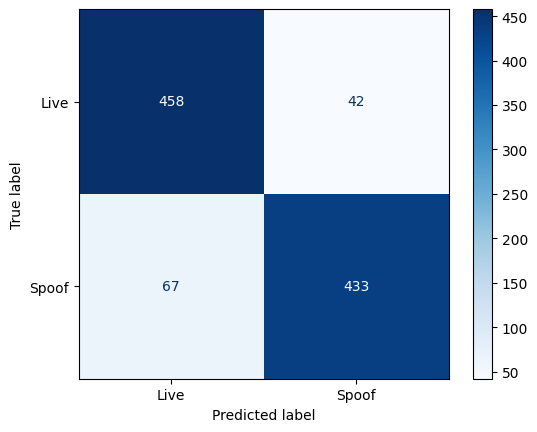

## ROC AUC

AUC: 0.9586
Optimal threshold (Youden): 0.1024
At this threshold: TPR=0.8480, FPR=0.0600


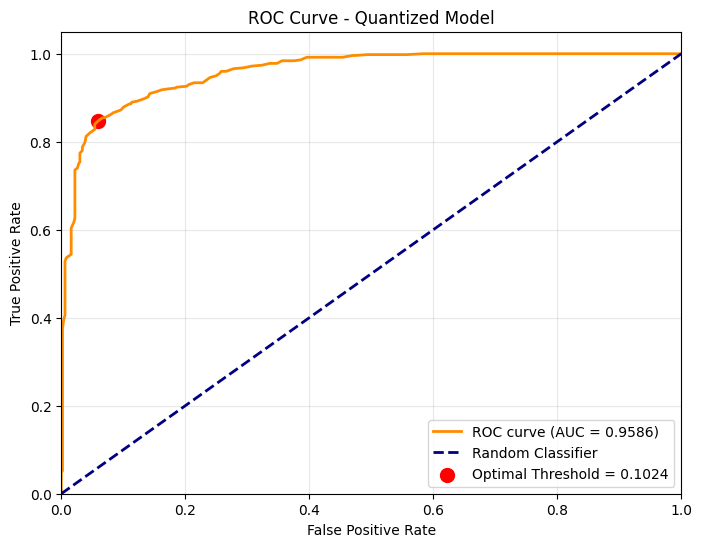

In [20]:
from sklearn.metrics import roc_curve, auc, roc_auc_score


all_probs = []
all_labels = []
with torch.no_grad():
    for i, (img, label) in enumerate(small_test_loader):
        img = img.to(device)

        outputs = session.run(None, {input_name: img.cpu().numpy()})[0]
        outputs = torch.tensor(outputs)
        predictions = torch.sigmoid(outputs)

        all_probs.extend(predictions.cpu().numpy())
        all_labels.extend(label.numpy())


all_probs = np.array(all_probs).flatten()
all_labels = np.array(all_labels).flatten()


fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

youden_index = tpr - fpr
best_idx = np.argmax(youden_index)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold (Youden): {best_threshold:.4f}")
print(f"At this threshold: TPR={tpr[best_idx]:.4f}, FPR={fpr[best_idx]:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2,
         linestyle='--', label='Random Classifier')
plt.scatter(fpr[best_idx], tpr[best_idx], marker='o', color='red',
            s=100, label=f'Optimal Threshold = {best_threshold:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Quantized Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

test_predictions = []
test_labels = []
with torch.no_grad():
    for i, (img, label) in enumerate(small_test_loader):
        img = img.to(device)

        outputs = session.run(None, {input_name: img.cpu().numpy()})[0]
        outputs = torch.tensor(outputs)
        predictions = torch.sigmoid(outputs)
        predictions = (predictions > 0.1024).int()

        test_predictions.extend(predictions.cpu().numpy())
        test_labels.extend(label.numpy())

# Calculate metrics

accuracy = accuracy_score(test_labels, test_predictions)
precision = precision_score(test_labels, test_predictions, zero_division=0)
recall = recall_score(test_labels, test_predictions, zero_division=0)
f1 = f1_score(test_labels, test_predictions, zero_division=0)
confusion_mat = confusion_matrix(test_labels, test_predictions)
display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_mat, display_labels=['Live', 'Spoof'])

Quantized Model Test Results:
Accuracy:  0.8930
Precision: 0.9396
Recall:    0.8400
F1 Score:  0.8870

Confusion Matrix:
[[473  27]
 [ 80 420]]


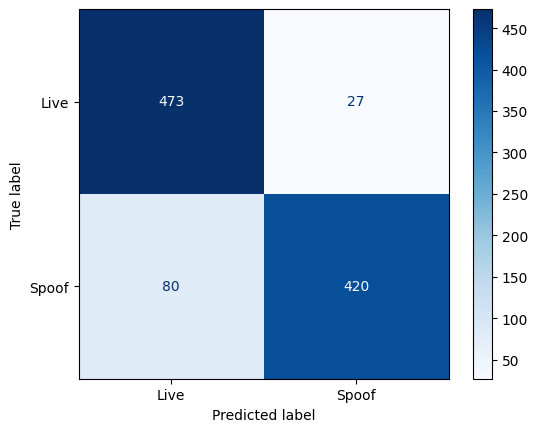

In [37]:
print(f"Quantized Model Test Results:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"\nConfusion Matrix:\n{confusion_mat}")


display.plot(cmap='Blues', values_format='d')
# plt.tight_layout()